<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/03-E02-Resampleo-Unificado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 2: Validación de Resampleo a 50 Hz — Métricas Mejoradas

**Objetivo:** Evaluar la calidad del resampleo de cada dataset a 50 Hz usando métricas que reflejan fidelidad morfológica real, no solo preservación de pico máximo.

**Mejoras respecto al Experimento 1:**
- Métricas correctas: SNR en banda válida, correlación de Pearson filtrada, DTW normalizado
- Resampleo sobre el trial completo (no sobre ventana corta)
- Método único estandarizado (`resample_poly`) para todos los datasets
- Detección del desfase temporal (phase shift) entre picos
- Resumen comparativo cross-dataset al final

**Datasets soportados:** SisFall (200 Hz) · UP-Fall (100 Hz) · FallAllD (238 Hz) · UMAFall (20 Hz)  
**Frecuencia objetivo:** 50 Hz

## 0 · Instalación y librerías

In [14]:
%pip install numpy pandas scipy dtaidistance azure-storage-file-datalake --quiet

In [15]:
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import resample_poly, welch, butter, filtfilt
from scipy.stats import pearsonr
from dtaidistance import dtw as dtw_lib
from google.colab import userdata
from azure.storage.filedatalake import DataLakeServiceClient

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.linestyle": "--", "grid.alpha": 0.45})

FS_TARGET = 50          # Hz objetivo global
EVAL_WINDOW_SEC = 2.0   # segundos alrededor del pico para análisis focal
KAISER_BETA = 5.0       # parámetro del filtro FIR de resample_poly (consistente en todos los DS)

print(f"Configuración: FS_TARGET={FS_TARGET} Hz | ventana de eval={EVAL_WINDOW_SEC}s | Kaiser β={KAISER_BETA}")

Configuración: FS_TARGET=50 Hz | ventana de eval=2.0s | Kaiser β=5.0


## 1 · Carga de datasets desde Azure Data Lake

Una sola celda que descarga los cuatro CSV.  
Si alguno no está disponible se omite sin romper el notebook.

In [16]:
# ── Conexión ──────────────────────────────────────────────────────────────
CONNECTION_STRING = userdata.get("cadenaAzure")
service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
fs_bronce = service_client.get_file_system_client("bronce")
dir_falls = fs_bronce.get_directory_client("falls")

def _load_csv(filename: str) -> pd.DataFrame | None:
    try:
        content = dir_falls.get_file_client(filename).download_file().readall()
        df = pd.read_csv(io.BytesIO(content))
        print(f"  ✓  {filename:35s}  →  {len(df):>8,} filas")
        return df
    except Exception as e:
        print(f"  ✗  {filename:35s}  →  ERROR: {e}")
        return None

print("Descargando datasets…")
datasets = {
    "SisFall":  {"df": _load_csv("SisFall-Reduced.csv"),  "fs": 200},
    "UPFall":   {"df": _load_csv("UPFall-Reduced.csv"),   "fs": 100},
    "FallAllD": {"df": _load_csv("FallAllD-Reduced.csv"), "fs": 238},
    "UMAFall":  {"df": _load_csv("UMAFall-Reduced.csv"),  "fs": 20},
}

# Diccionario global donde se irán acumulando los resultados de cada sección
RESULTS: dict[str, dict] = {}

print("\nCarga completa.")

Descargando datasets…
  ✓  SisFall-Reduced.csv                  →  15,858,929 filas
  ✓  UPFall-Reduced.csv                   →   294,678 filas
  ✓  FallAllD-Reduced.csv                 →  8,558,480 filas
  ✓  UMAFall-Reduced.csv                  →   184,100 filas

Carga completa.


## 2 · Funciones de análisis compartidas

Estas funciones son reutilizadas por cada sección de dataset.  
**No modificar entre secciones** — son el núcleo del experimento mejorado.

In [17]:
# ── Resampleo ─────────────────────────────────────────────────────────────
def get_poly_factors(fs_orig: int, fs_target: int) -> tuple[int, int]:
    """Devuelve (up, down) reducidos al mínimo común divisor."""
    from math import gcd
    g = gcd(fs_target, fs_orig)
    return fs_target // g, fs_orig // g


def resample_trial(signal: np.ndarray, fs_orig: int, fs_target: int) -> np.ndarray:
    """
    Resamplea un trial COMPLETO con resample_poly y filtro Kaiser consistente.
    Operar sobre el trial completo evita artefactos de borde (efecto Gibbs)
    que aparecen cuando se resamplea una ventana corta alrededor del pico.
    """
    up, down = get_poly_factors(fs_orig, fs_target)
    return resample_poly(signal, up=up, down=down, window=("kaiser", KAISER_BETA))


# ── Filtro pasa-bajos de referencia ───────────────────────────────────────────
def lowpass(signal: np.ndarray, fs: int, cutoff: float = None) -> np.ndarray:
    """
    Filtra la señal original al mismo ancho de banda que la señal resampleada
    (Nyquist del target = FS_TARGET/2).  Permite comparar señales en la misma
    banda antes de calcular correlación/SNR, eliminando la ventaja artificial
    de la señal original al tener contenido de alta frecuencia.
    """
    if cutoff is None:
        cutoff = FS_TARGET / 2.0 - 0.5   # ligeramente por debajo de Nyquist
    nyq = fs / 2.0
    b, a = butter(8, cutoff / nyq, btype="low")
    return filtfilt(b, a, signal)


# ── Métricas ──────────────────────────────────────────────────────────────────
def snr_inband(orig: np.ndarray, resampled: np.ndarray,
               fs_orig: int, fs_target: int) -> float:
    """
    SNR en la banda válida [0, FS_TARGET/2] Hz.
    Señal = la parte de la original que SÍ puede representar el resampleo.
    Ruido  = diferencia entre esa señal de referencia y la resampleada
             interpolada al mismo eje temporal.
    """
    # Interpolar resampleada al eje temporal de la original para poder restar
    n_orig = len(orig)
    n_res  = len(resampled)
    t_orig = np.linspace(0, 1, n_orig)
    t_res  = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)

    orig_filtered = lowpass(orig, fs_orig)
    noise = orig_filtered - resampled_interp
    power_signal = np.mean(orig_filtered ** 2)
    power_noise  = np.mean(noise ** 2)
    if power_noise == 0:
        return np.inf
    return 10 * np.log10(power_signal / power_noise)


def pearson_inband(orig: np.ndarray, resampled: np.ndarray,
                   fs_orig: int) -> float:
    """
    Correlación de Pearson entre la original filtrada a la banda del target
    y la resampleada (interpolada al eje temporal de la original).
    Mide similitud morfológica.
    """
    n_orig = len(orig)
    n_res  = len(resampled)
    t_orig = np.linspace(0, 1, n_orig)
    t_res  = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)
    orig_filtered    = lowpass(orig, fs_orig)
    r, _ = pearsonr(orig_filtered, resampled_interp)
    return r


def dtw_normalized(orig: np.ndarray, resampled: np.ndarray,
                   fs_orig: int, fs_target: int) -> float:
    """
    Distancia DTW normalizada por la longitud de la secuencia más larga.
    Ambas señales se normalizan (zscore) antes de comparar para que la escala
    no domine y lo que se mida sea la similitud de forma (shape).
    Se submuestrea a FS_TARGET para comparar señales del mismo tamaño.
    """
    up, down = get_poly_factors(fs_orig, fs_target)
    orig_resampled_to_target = resample_poly(orig, up=up, down=down,
                                              window=("kaiser", KAISER_BETA))

    def zscore(x):
        s = x.std()
        return (x - x.mean()) / s if s > 0 else x - x.mean()

    a = zscore(orig_resampled_to_target).astype(np.double)
    b = zscore(resampled).astype(np.double)
    # Limitar longitud para performance (máx 500 muestras = 10s a 50 Hz)
    max_len = 500
    if len(a) > max_len:
        a = a[:max_len]
        b = b[:max_len]
    dist = dtw_lib.distance_fast(a, b)
    return dist / max(len(a), len(b))


def peak_phase_shift_ms(orig: np.ndarray, resampled: np.ndarray,
                         fs_orig: int, fs_target: int) -> float:
    """
    Desfase temporal entre el pico de la original y el pico de la resampleada,
    expresado en milisegundos.  Un desfase alto indica que el resampleo
    desplaza la localización del evento de impacto en el tiempo.
    """
    t_peak_orig = orig.argmax() / fs_orig
    t_peak_res  = resampled.argmax() / fs_target
    return abs(t_peak_orig - t_peak_res) * 1000   # ms


def peak_attenuation_pct(orig: np.ndarray, resampled: np.ndarray,
                          fs_orig: int) -> float:
    """
    Atenuación del pico relativa a la señal original FILTRADA (no a la cruda).
    Al comparar contra la señal filtrada se elimina la energía que el filtro
    antialiasing correctamente debe eliminar, midiendo solo la degradación
    real sobre la banda que sí debería conservarse.
    """
    orig_filtered = lowpass(orig, fs_orig)
    max_orig = np.max(orig_filtered)
    n_res    = len(resampled)
    n_orig   = len(orig)
    t_orig   = np.linspace(0, 1, n_orig)
    t_res    = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)
    max_res  = np.max(resampled_interp)
    return abs(max_orig - max_res) / max_orig * 100 if max_orig > 0 else 0.0


# ── Pipeline de análisis por trial ────────────────────────────────────────────
def analyze_trial(trial_df: pd.DataFrame, fs_orig: int,
                  fs_target: int = FS_TARGET) -> dict | None:
    """
    Analiza un trial completo:
      1. Calcula las resultantes de acelerómetro y giroscopio
      2. Resamplea el trial COMPLETO
      3. Extrae ventana focal alrededor del pico (en la señal resampleada)
      4. Calcula las 5 métricas para cada sensor
    """
    a_res = np.sqrt(trial_df["Ax"]**2 + trial_df["Ay"]**2 + trial_df["Az"]**2).values
    g_res = np.sqrt(trial_df["Gx"]**2 + trial_df["Gy"]**2 + trial_df["Gz"]**2).values

    if len(a_res) < fs_orig:   # trial demasiado corto
        return None

    # Resamplear el trial completo
    a_res_r = resample_trial(a_res, fs_orig, fs_target)
    g_res_r = resample_trial(g_res, fs_orig, fs_target)

    # Ventana focal alrededor del pico (en la señal resampleada)
    w = int(EVAL_WINDOW_SEC / 2 * fs_target)
    peak_r = a_res_r.argmax()
    s, e = max(0, peak_r - w), min(len(a_res_r), peak_r + w)

    # Ventana correspondiente en la señal original (misma duración temporal)
    ratio = fs_orig / fs_target
    peak_o = a_res.argmax()
    wo = int(EVAL_WINDOW_SEC / 2 * fs_orig)
    so, eo = max(0, peak_o - wo), min(len(a_res), peak_o + wo)

    win_a_orig = a_res[so:eo]
    win_a_res  = a_res_r[s:e]
    win_g_orig = g_res[so:eo]
    win_g_res  = g_res_r[s:e]

    result = {}
    for sensor, orig, resampled in [("acc", win_a_orig, win_a_res),
                                     ("gyro", win_g_orig, win_g_res)]:
        result[sensor] = {
            "snr_db":          snr_inband(orig, resampled, fs_orig, fs_target),
            "pearson_r":       pearson_inband(orig, resampled, fs_orig),
            "dtw_norm":        dtw_normalized(orig, resampled, fs_orig, fs_target),
            "phase_shift_ms":  peak_phase_shift_ms(orig, resampled, fs_orig, fs_target),
            "peak_atten_pct":  peak_attenuation_pct(orig, resampled, fs_orig),
        }
    return result


# ── Loop de validación global ─────────────────────────────────────────────────
def run_global_validation(df: pd.DataFrame, fs_orig: int,
                           label: str = "Fall") -> pd.DataFrame:
    """
    Itera sobre todos los trials de la clase indicada y devuelve un DataFrame
    con las métricas por trial, más el resumen estadístico impreso.
    """
    falls = df[df["Activity_Label"] == label]
    trials = falls[["Subject", "Activity_Code", "Trial"]].drop_duplicates()
    print(f"  Procesando {len(trials)} trials ({label})…")

    rows = []
    for _, row in trials.iterrows():
        mask = ((falls["Subject"]       == row["Subject"]) &
                (falls["Activity_Code"] == row["Activity_Code"]) &
                (falls["Trial"]         == row["Trial"]))
        trial_df = falls[mask]
        r = analyze_trial(trial_df, fs_orig)
        if r is None:
            continue
        for sensor in ("acc", "gyro"):
            rows.append({"sensor": sensor, **r[sensor]})

    return pd.DataFrame(rows)


def print_summary(df_metrics: pd.DataFrame, dataset_name: str, fs_orig: int):
    """Imprime tabla de estadísticos por sensor."""
    print(f"\n{'='*60}")
    print(f"  {dataset_name}  |  {fs_orig} Hz  →  {FS_TARGET} Hz")
    print(f"{'='*60}")
    cols = ["snr_db", "pearson_r", "dtw_norm", "phase_shift_ms", "peak_atten_pct"]
    for sensor in ("acc", "gyro"):
        sub = df_metrics[df_metrics["sensor"] == sensor][cols]
        print(f"\n  Sensor: {sensor.upper()}")
        print(f"  {'Métrica':<20} {'Media':>8} {'P50':>8} {'P95':>8} {'Máx':>8}")
        print(f"  {'-'*56}")
        labels = {
            "snr_db":          "SNR in-band (dB)",
            "pearson_r":       "Pearson r",
            "dtw_norm":        "DTW normalizado",
            "phase_shift_ms":  "Phase shift (ms)",
            "peak_atten_pct":  "Aten. pico filtrado (%)",
        }
        for col in cols:
            vals = sub[col].dropna()
            print(f"  {labels[col]:<20} {vals.mean():>8.3f} "
                  f"{vals.median():>8.3f} "
                  f"{vals.quantile(0.95):>8.3f} "
                  f"{vals.max():>8.3f}")
    print()


print("Funciones cargadas correctamente.")

Funciones cargadas correctamente.


---
## 3 · SisFall — 200 Hz → 50 Hz

Downsampling entero (factor 4). La señal tiene componentes de alta frecuencia que el filtro antialiasing correctamente elimina.
Analizar aquí si la morfología del evento sobrevive en la banda 0–25 Hz.

In [18]:
DS_NAME = "SisFall"
info = datasets[DS_NAME]
assert info["df"] is not None, f"Dataset {DS_NAME} no disponible"

df_sf = info["df"]
FS_SF = info["fs"]    # 200 Hz
print(f"{DS_NAME}: {len(df_sf):,} filas | fs_orig={FS_SF} Hz | caídas: {(df_sf['Activity_Label']=='Fall').sum():,}")

SisFall: 15,858,929 filas | fs_orig=200 Hz | caídas: 5,393,714


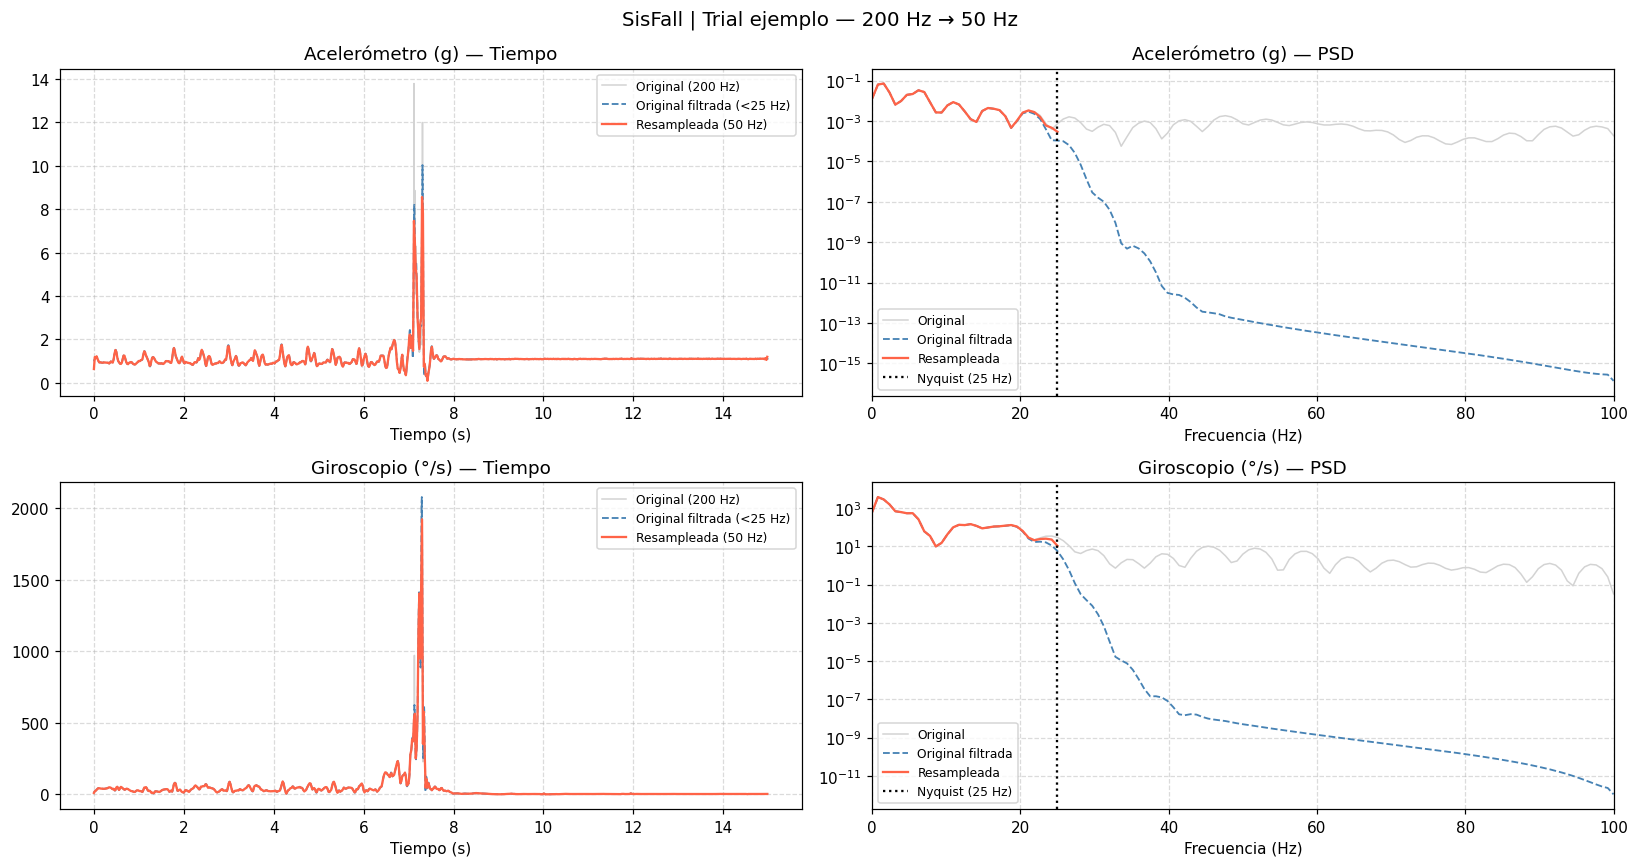

In [19]:
# ── 3a. Visualización de un trial de ejemplo ──────────────────────────────
sf_falls  = df_sf[df_sf["Activity_Label"] == "Fall"]
sf_ej     = sf_falls[["Subject","Activity_Code","Trial"]].drop_duplicates().iloc[0]
sf_trial  = sf_falls[(sf_falls["Subject"]       == sf_ej["Subject"]) &
                      (sf_falls["Activity_Code"] == sf_ej["Activity_Code"]) &
                      (sf_falls["Trial"]         == sf_ej["Trial"])]

a_orig = np.sqrt(sf_trial["Ax"]**2 + sf_trial["Ay"]**2 + sf_trial["Az"]**2).values
g_orig = np.sqrt(sf_trial["Gx"]**2 + sf_trial["Gy"]**2 + sf_trial["Gz"]**2).values

# Resamplear el trial COMPLETO
a_res = resample_trial(a_orig, FS_SF, FS_TARGET)
g_res = resample_trial(g_orig, FS_SF, FS_TARGET)

# Ejes temporales
t_orig = np.arange(len(a_orig)) / FS_SF
t_res  = np.arange(len(a_res))  / FS_TARGET

# Señal original filtrada a la misma banda (referencia justa)
a_filt = lowpass(a_orig, FS_SF)
g_filt = lowpass(g_orig, FS_SF)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Trial ejemplo — {FS_SF} Hz → {FS_TARGET} Hz", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",    a_orig, a_filt, a_res),
        ("Giroscopio (°/s)",    g_orig, g_filt, g_res)]):

    # Dominio del tiempo
    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label=f"Original ({FS_SF} Hz)")
    ax.plot(t_orig, filt,      color="steelblue", lw=1.2, label=f"Original filtrada (<{FS_TARGET//2} Hz)", ls="--")
    ax.plot(t_res,  resampled, color="tomato",    lw=1.5, label=f"Resampleada ({FS_TARGET} Hz)")
    ax.set_title(f"{name} — Tiempo")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    # Dominio frecuencial (PSD)
    ax = axes[row, 1]
    nperseg_o = min(256, len(orig)//2)
    nperseg_r = min(64,  len(resampled)//2)
    fo, Po = welch(orig,      fs=FS_SF,     nperseg=nperseg_o)
    ff, Pf = welch(filt,      fs=FS_SF,     nperseg=nperseg_o)
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(fo, Po, color="lightgray", lw=1,   label="Original")
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label=f"Nyquist ({FS_TARGET//2} Hz)")
    ax.set_xlim(0, FS_SF//2)
    ax.set_title(f"{name} — PSD")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
# ── 3b. Validación global ─────────────────────────────────────────────────
sf_metrics = run_global_validation(df_sf, FS_SF)
print_summary(sf_metrics, DS_NAME, FS_SF)
RESULTS[DS_NAME] = {"metrics": sf_metrics, "fs_orig": FS_SF}

  Procesando 1798 trials (Fall)…

  SisFall  |  200 Hz  →  50 Hz

  Sensor: ACC
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       16.236   16.054   27.194   38.630
  Pearson r               0.901    0.952    0.995    0.998
  DTW normalizado         0.021    0.020    0.042    0.078
  Phase shift (ms)        0.150    0.000    0.000  270.000
  Aten. pico filtrado (%)    6.378    5.423   14.713  102.556

  Sensor: GYRO
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       19.262   19.228   29.804   36.159
  Pearson r               0.951    0.986    0.999    1.000
  DTW normalizado         0.012    0.010    0.027    0.122
  Phase shift (ms)       24.650   10.000   90.000  995.000
  Aten. pico filtrado (%)    4.397    3.032   12.186  353.333



---
## 4 · UP-Fall — 100 Hz → 50 Hz

Downsampling factor 2. Caso intermedio: la razón es entera y limpia, pero se pierde la banda 25–50 Hz.

In [21]:
DS_NAME = "UPFall"
info = datasets[DS_NAME]
assert info["df"] is not None, f"Dataset {DS_NAME} no disponible"

df_up = info["df"]
FS_UP = info["fs"]    # 100 Hz
print(f"{DS_NAME}: {len(df_up):,} filas | fs_orig={FS_UP} Hz | caídas: {(df_up['Activity_Label']=='Fall').sum():,}")

UPFall: 294,678 filas | fs_orig=100 Hz | caídas: 45,951


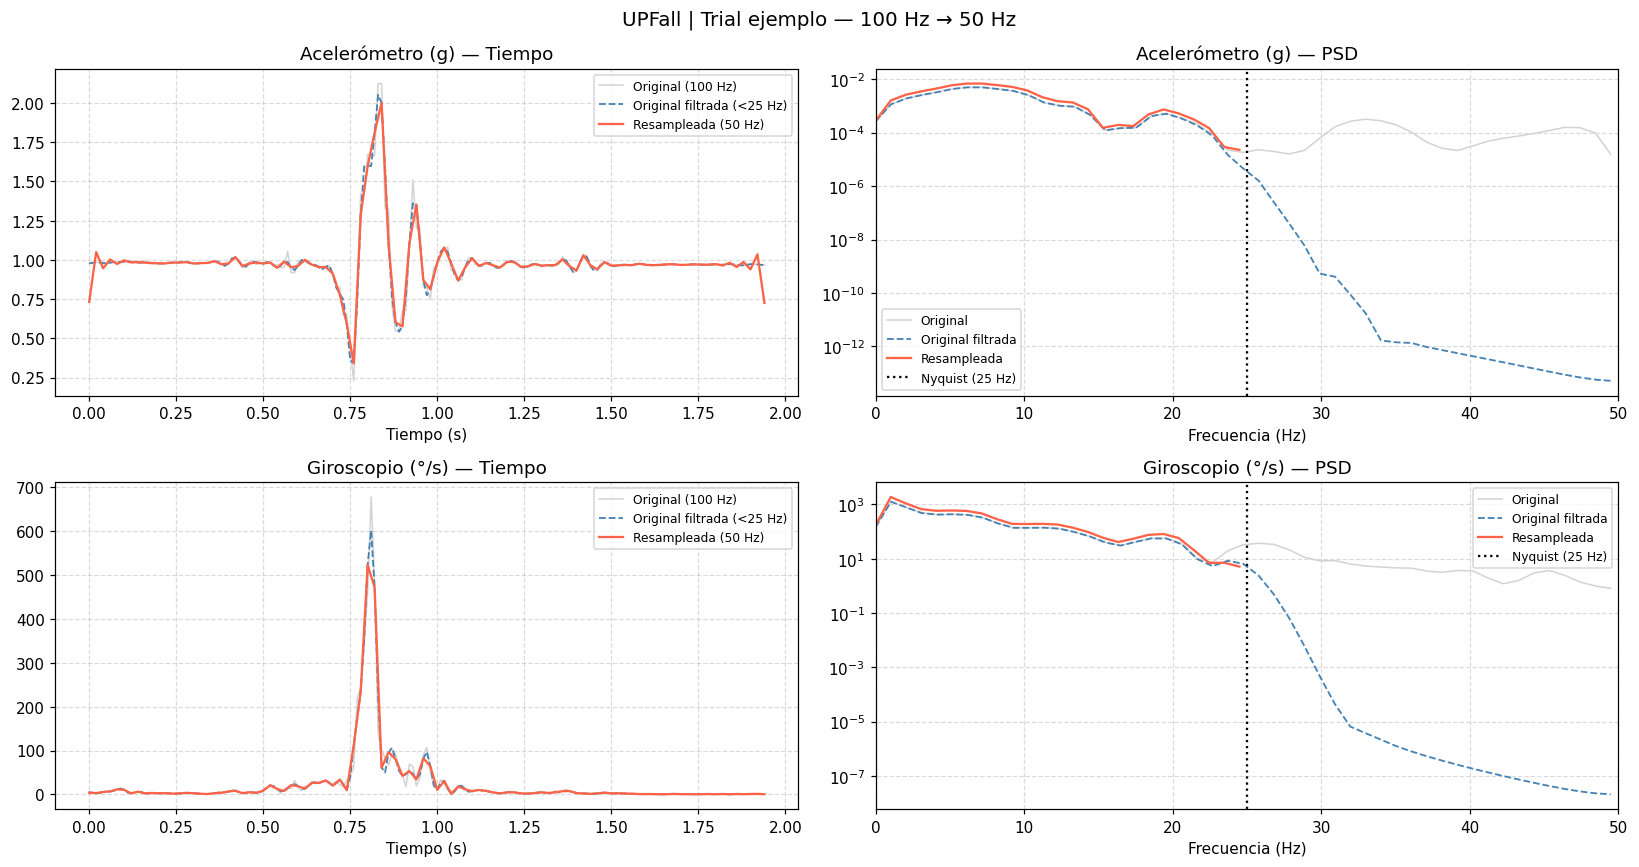

In [22]:
# ── 4a. Visualización de un trial de ejemplo ──────────────────────────────
up_falls  = df_up[df_up["Activity_Label"] == "Fall"]
up_ej     = up_falls[["Subject","Activity_Code","Trial"]].drop_duplicates().iloc[0]
up_trial  = up_falls[(up_falls["Subject"]       == up_ej["Subject"]) &
                      (up_falls["Activity_Code"] == up_ej["Activity_Code"]) &
                      (up_falls["Trial"]         == up_ej["Trial"])]

a_orig = np.sqrt(up_trial["Ax"]**2 + up_trial["Ay"]**2 + up_trial["Az"]**2).values
g_orig = np.sqrt(up_trial["Gx"]**2 + up_trial["Gy"]**2 + up_trial["Gz"]**2).values

a_res = resample_trial(a_orig, FS_UP, FS_TARGET)
g_res = resample_trial(g_orig, FS_UP, FS_TARGET)

t_orig = np.arange(len(a_orig)) / FS_UP
t_res  = np.arange(len(a_res))  / FS_TARGET
a_filt = lowpass(a_orig, FS_UP)
g_filt = lowpass(g_orig, FS_UP)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Trial ejemplo — {FS_UP} Hz → {FS_TARGET} Hz", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",  a_orig, a_filt, a_res),
        ("Giroscopio (°/s)", g_orig, g_filt, g_res)]):

    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label=f"Original ({FS_UP} Hz)")
    ax.plot(t_orig, filt,      color="steelblue", lw=1.2, ls="--", label=f"Original filtrada (<{FS_TARGET//2} Hz)")
    ax.plot(t_res,  resampled, color="tomato",    lw=1.5, label=f"Resampleada ({FS_TARGET} Hz)")
    ax.set_title(f"{name} — Tiempo")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    nperseg_o = min(256, len(orig)//2)
    nperseg_r = min(64,  len(resampled)//2)
    fo, Po = welch(orig,      fs=FS_UP,     nperseg=nperseg_o)
    ff, Pf = welch(filt,      fs=FS_UP,     nperseg=nperseg_o)
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(fo, Po, color="lightgray", lw=1,   label="Original")
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label=f"Nyquist ({FS_TARGET//2} Hz)")
    ax.set_xlim(0, FS_UP//2)
    ax.set_title(f"{name} — PSD")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [23]:
# ── 4b. Validación global ─────────────────────────────────────────────────
up_metrics = run_global_validation(df_up, FS_UP)
print_summary(up_metrics, DS_NAME, FS_UP)
RESULTS[DS_NAME] = {"metrics": up_metrics, "fs_orig": FS_UP}

  Procesando 255 trials (Fall)…

  UPFall  |  100 Hz  →  50 Hz

  Sensor: ACC
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       20.880   20.789   25.437   29.650
  Pearson r               0.929    0.956    0.979    0.989
  DTW normalizado         0.009    0.008    0.018    0.063
  Phase shift (ms)        7.765   10.000   20.000  130.000
  Aten. pico filtrado (%)    9.441    8.938   19.550   25.169

  Sensor: GYRO
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       17.652   17.781   23.232   25.719
  Pearson r               0.983    0.989    0.997    0.998
  DTW normalizado         0.001    0.000    0.001    0.052
  Phase shift (ms)       12.745   10.000   50.000  230.000
  Aten. pico filtrado (%)    6.827    6.589   16.575   29.637



---
## 5 · FallAllD — 238 Hz → 50 Hz

Caso polifásico: razón 50/238 = 25/119, no entera. `resample_poly` maneja esto correctamente con un filtro FIR polifásico.

In [24]:
DS_NAME = "FallAllD"
info = datasets[DS_NAME]
assert info["df"] is not None, f"Dataset {DS_NAME} no disponible"

df_fa = info["df"]
FS_FA = info["fs"]    # 238 Hz
print(f"{DS_NAME}: {len(df_fa):,} filas | fs_orig={FS_FA} Hz | caídas: {(df_fa['Activity_Label']=='Fall').sum():,}")
up_f, down_f = get_poly_factors(FS_FA, FS_TARGET)
print(f"Factores polifásicos: up={up_f}, down={down_f}  →  {FS_FA} × {up_f}/{down_f} = {FS_FA*up_f/down_f:.4f} Hz")

FallAllD: 8,558,480 filas | fs_orig=238 Hz | caídas: 2,218,160
Factores polifásicos: up=25, down=119  →  238 × 25/119 = 50.0000 Hz


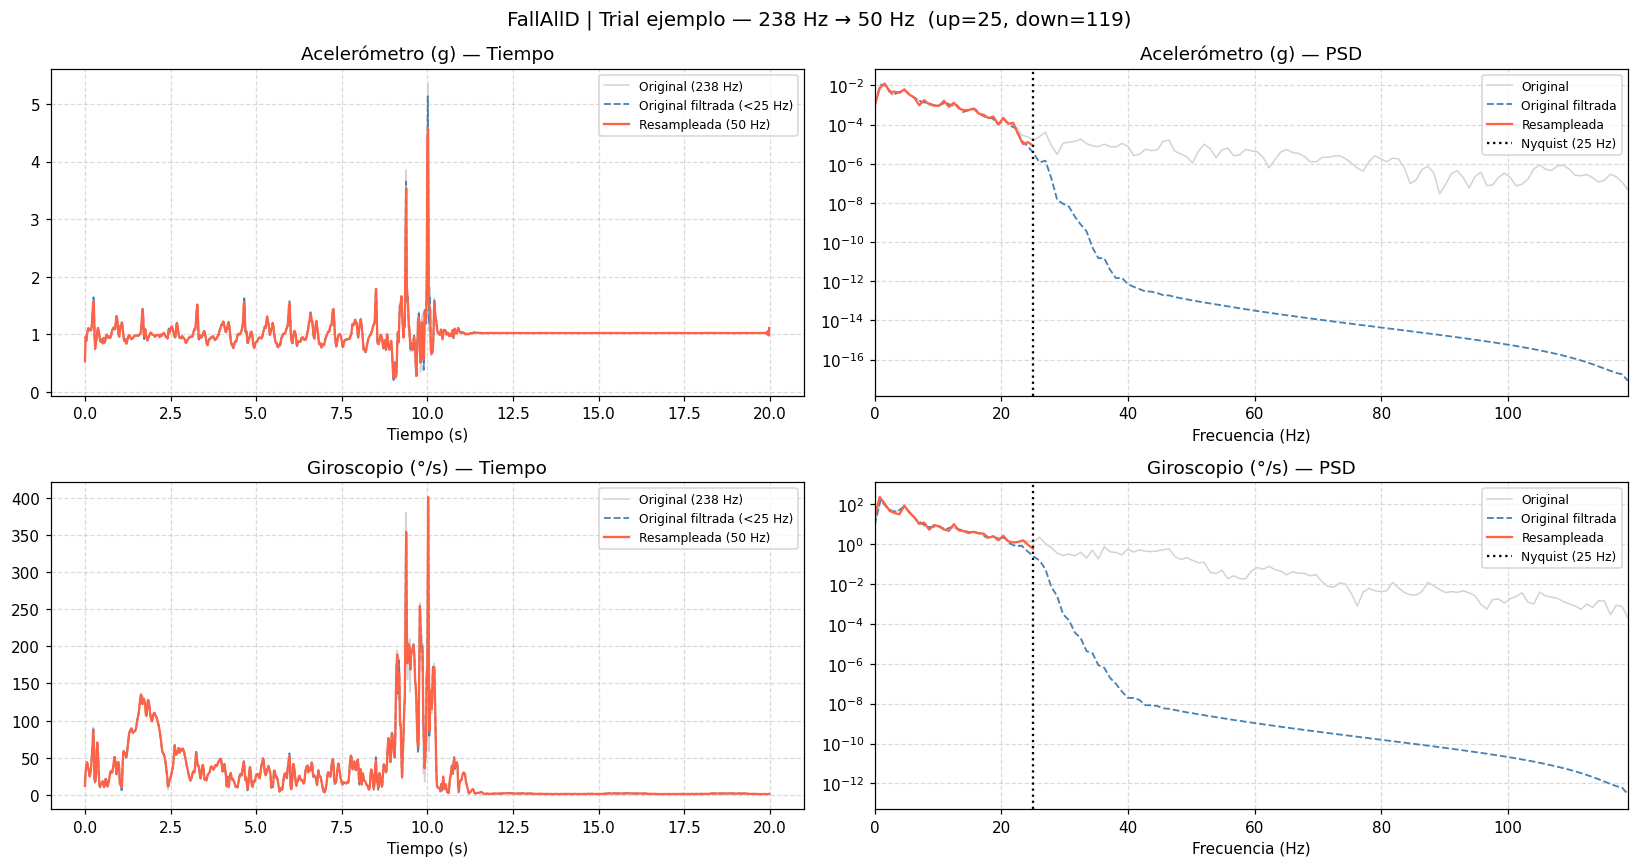

In [25]:
# ── 5a. Visualización de un trial de ejemplo ──────────────────────────────
fa_falls  = df_fa[df_fa["Activity_Label"] == "Fall"]
fa_ej     = fa_falls[["Subject","Activity_Code","Trial"]].drop_duplicates().iloc[0]
fa_trial  = fa_falls[(fa_falls["Subject"]       == fa_ej["Subject"]) &
                      (fa_falls["Activity_Code"] == fa_ej["Activity_Code"]) &
                      (fa_falls["Trial"]         == fa_ej["Trial"])]

a_orig = np.sqrt(fa_trial["Ax"]**2 + fa_trial["Ay"]**2 + fa_trial["Az"]**2).values
g_orig = np.sqrt(fa_trial["Gx"]**2 + fa_trial["Gy"]**2 + fa_trial["Gz"]**2).values

a_res = resample_trial(a_orig, FS_FA, FS_TARGET)
g_res = resample_trial(g_orig, FS_FA, FS_TARGET)

t_orig = np.arange(len(a_orig)) / FS_FA
t_res  = np.arange(len(a_res))  / FS_TARGET
a_filt = lowpass(a_orig, FS_FA)
g_filt = lowpass(g_orig, FS_FA)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Trial ejemplo — {FS_FA} Hz → {FS_TARGET} Hz  (up={up_f}, down={down_f})", fontsize=13)

for row, (name, orig, filt, resampled) in enumerate([
        ("Acelerómetro (g)",  a_orig, a_filt, a_res),
        ("Giroscopio (°/s)", g_orig, g_filt, g_res)]):

    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="lightgray", lw=1,   label=f"Original ({FS_FA} Hz)")
    ax.plot(t_orig, filt,      color="steelblue", lw=1.2, ls="--", label=f"Original filtrada (<{FS_TARGET//2} Hz)")
    ax.plot(t_res,  resampled, color="tomato",    lw=1.5, label=f"Resampleada ({FS_TARGET} Hz)")
    ax.set_title(f"{name} — Tiempo")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    nperseg_o = min(256, len(orig)//2)
    nperseg_r = min(64,  len(resampled)//2)
    fo, Po = welch(orig,      fs=FS_FA,     nperseg=nperseg_o)
    ff, Pf = welch(filt,      fs=FS_FA,     nperseg=nperseg_o)
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(fo, Po, color="lightgray", lw=1,   label="Original")
    ax.semilogy(ff, Pf, color="steelblue", lw=1.2, ls="--", label="Original filtrada")
    ax.semilogy(fr, Pr, color="tomato",    lw=1.5, label="Resampleada")
    ax.axvline(FS_TARGET/2, color="black", ls=":", label=f"Nyquist ({FS_TARGET//2} Hz)")
    ax.set_xlim(0, FS_FA//2)
    ax.set_title(f"{name} — PSD")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [26]:
# ── 5b. Validación global ─────────────────────────────────────────────────
fa_metrics = run_global_validation(df_fa, FS_FA)
print_summary(fa_metrics, DS_NAME, FS_FA)
RESULTS[DS_NAME] = {"metrics": fa_metrics, "fs_orig": FS_FA}

  Procesando 466 trials (Fall)…

  FallAllD  |  238 Hz  →  50 Hz

  Sensor: ACC
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       14.675   14.297   23.998   32.382
  Pearson r               0.824    0.903    0.988    0.997
  DTW normalizado         0.027    0.024    0.050    0.090
  Phase shift (ms)        3.621    0.000    0.000  900.000
  Aten. pico filtrado (%)    6.181    4.653   16.102   54.407

  Sensor: GYRO
  Métrica                 Media      P50      P95      Máx
  --------------------------------------------------------
  SNR in-band (dB)       14.945   15.207   25.271   31.059
  Pearson r               0.872    0.959    0.996    0.999
  DTW normalizado         0.019    0.016    0.045    0.095
  Phase shift (ms)       65.877   10.084  420.798  988.403
  Aten. pico filtrado (%)    5.745    3.399   16.344   73.956



---
## 6 · UMAFall — 20 Hz → 50 Hz

Upsampling (factor 2.5 = up=5, down=2). El 60 % de los datos resultantes son sintéticos. El análisis busca detectar overshoot del interpolador y evaluar si la morfología se mantiene consistente.

In [27]:
DS_NAME = "UMAFall"
info = datasets[DS_NAME]
assert info["df"] is not None, f"Dataset {DS_NAME} no disponible"

df_um = info["df"]
FS_UM = info["fs"]    # 20 Hz
print(f"{DS_NAME}: {len(df_um):,} filas | fs_orig={FS_UM} Hz | caídas: {(df_um['Activity_Label']=='Fall').sum():,}")
up_u, down_u = get_poly_factors(FS_UM, FS_TARGET)
print(f"Factores de upsampling: up={up_u}, down={down_u}  →  {FS_UM} × {up_u}/{down_u} = {FS_UM*up_u/down_u:.1f} Hz")

UMAFall: 184,100 filas | fs_orig=20 Hz | caídas: 56,428
Factores de upsampling: up=5, down=2  →  20 × 5/2 = 50.0 Hz


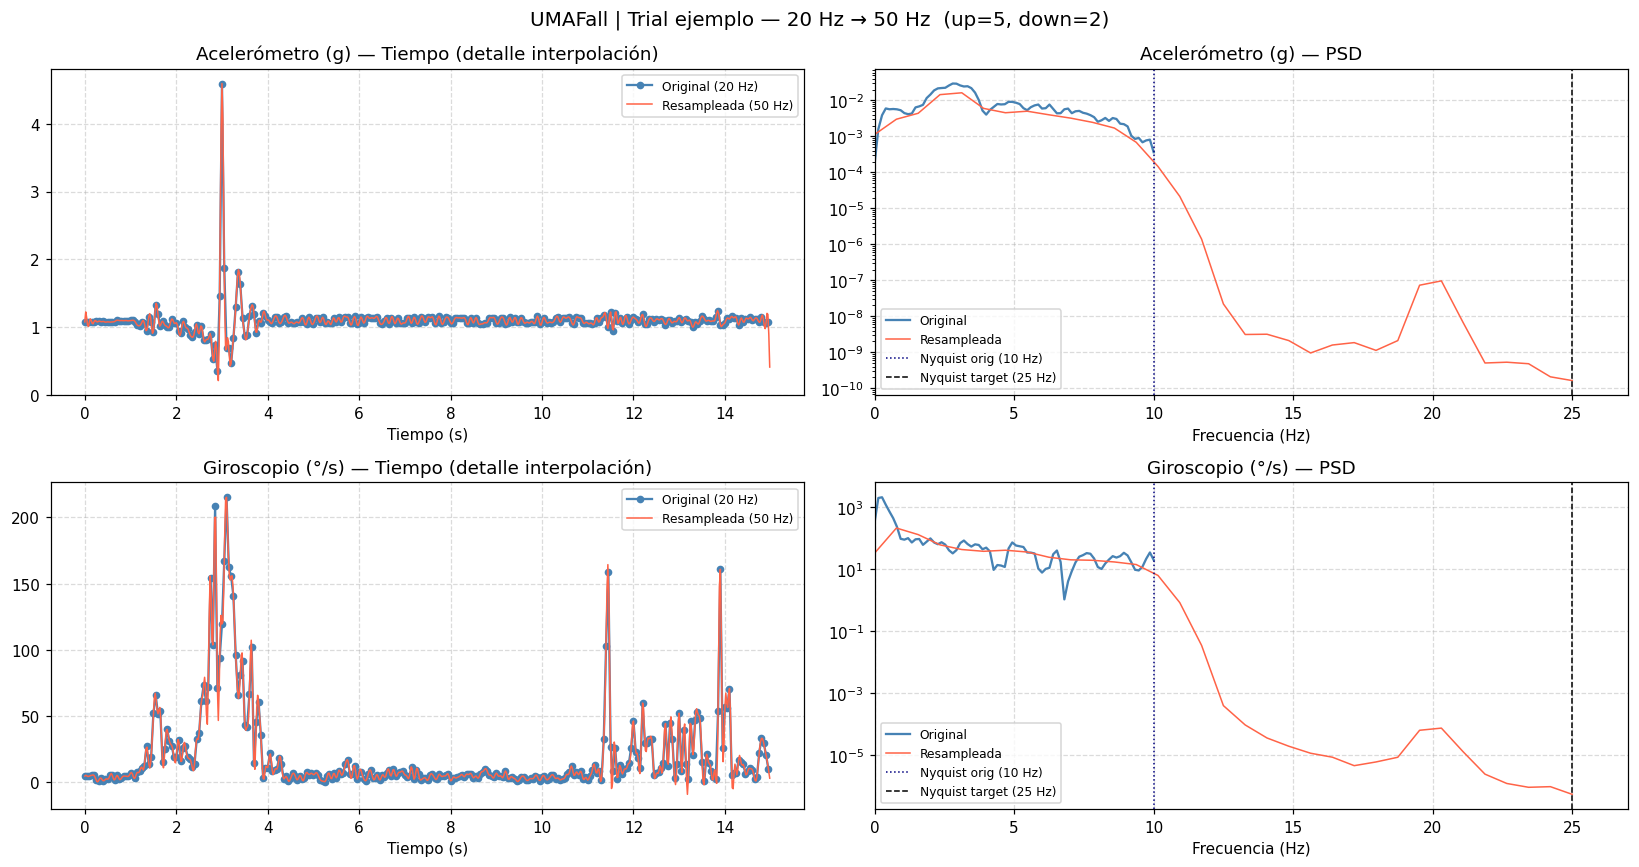

In [28]:
# ── 6a. Visualización de un trial de ejemplo ──────────────────────────────
um_falls  = df_um[df_um["Activity_Label"] == "Fall"]
um_ej     = um_falls[["Subject","Activity_Code","Trial"]].drop_duplicates().iloc[0]
um_trial  = um_falls[(um_falls["Subject"]       == um_ej["Subject"]) &
                      (um_falls["Activity_Code"] == um_ej["Activity_Code"]) &
                      (um_falls["Trial"]         == um_ej["Trial"])]

a_orig = np.sqrt(um_trial["Ax"]**2 + um_trial["Ay"]**2 + um_trial["Az"]**2).values
g_orig = np.sqrt(um_trial["Gx"]**2 + um_trial["Gy"]**2 + um_trial["Gz"]**2).values

a_res = resample_trial(a_orig, FS_UM, FS_TARGET)
g_res = resample_trial(g_orig, FS_UM, FS_TARGET)

t_orig = np.arange(len(a_orig)) / FS_UM
t_res  = np.arange(len(a_res))  / FS_TARGET

# Para UMAFall no se aplica lowpass de referencia (la señal orig ya está
# limitada a 10 Hz por su Nyquist natural). Se grafica tal cual.
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f"{DS_NAME} | Trial ejemplo — {FS_UM} Hz → {FS_TARGET} Hz  (up={up_u}, down={down_u})", fontsize=13)

for row, (name, orig, resampled) in enumerate([
        ("Acelerómetro (g)",  a_orig, a_res),
        ("Giroscopio (°/s)", g_orig, g_res)]):

    ax = axes[row, 0]
    ax.plot(t_orig, orig,      color="steelblue", lw=1.5, marker="o", ms=4, label=f"Original ({FS_UM} Hz)")
    ax.plot(t_res,  resampled, color="tomato",    lw=1,   label=f"Resampleada ({FS_TARGET} Hz)")
    ax.set_title(f"{name} — Tiempo (detalle interpolación)")
    ax.set_xlabel("Tiempo (s)")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    nperseg_o = max(4, len(orig)//2)
    nperseg_r = min(64, len(resampled)//2)
    fo, Po = welch(orig,      fs=FS_UM,     nperseg=nperseg_o)
    fr, Pr = welch(resampled, fs=FS_TARGET, nperseg=nperseg_r)
    ax.semilogy(fo, Po, color="steelblue", lw=1.5, label="Original")
    ax.semilogy(fr, Pr, color="tomato",    lw=1,   label="Resampleada")
    ax.axvline(FS_UM/2,     color="navy",  ls=":",  lw=1, label=f"Nyquist orig ({FS_UM//2} Hz)")
    ax.axvline(FS_TARGET/2, color="black", ls="--", lw=1, label=f"Nyquist target ({FS_TARGET//2} Hz)")
    ax.set_xlim(0, FS_TARGET//2 + 2)
    ax.set_title(f"{name} — PSD")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
# ── 6b. Validación global ─────────────────────────────────────────────────
um_metrics = run_global_validation(df_um, FS_UM)
print_summary(um_metrics, DS_NAME, FS_UM)
RESULTS[DS_NAME] = {"metrics": um_metrics, "fs_orig": FS_UM}

  Procesando 180 trials (Fall)…


ValueError: Digital filter critical frequencies must be 0 < Wn < 1

---
## 7 · Resumen comparativo cross-dataset

Ejecutar esta sección **después** de haber corrido todas las secciones de dataset que se quieran incluir.  
Compara visualmente los cinco indicadores para entender qué dataset sale mejor o peor parado al resamplear a 50 Hz.

In [31]:
assert RESULTS, "No hay resultados. Ejecutá al menos una sección de dataset primero."

# ── 7a. Tabla resumen ─────────────────────────────────────────────────────
metrics_order = ["snr_db", "pearson_r", "dtw_norm", "phase_shift_ms", "peak_atten_pct"]
metric_labels = {
    "snr_db":          "SNR in-band (dB)  ↑ mejor",
    "pearson_r":       "Pearson r          ↑ mejor",
    "dtw_norm":        "DTW norm.          ↓ mejor",
    "phase_shift_ms":  "Phase shift (ms)   ↓ mejor",
    "peak_atten_pct":  "Aten. pico filt. % ↓ mejor",
}

summary_rows = []
for ds_name, res in RESULTS.items():
    fs_o = res["fs_orig"]
    df_m = res["metrics"]
    for sensor in ("acc", "gyro"):
        sub = df_m[df_m["sensor"] == sensor]
        row = {"Dataset": ds_name, "fs_orig": fs_o, "Sensor": sensor.upper()}
        for m in metrics_order:
            row[m + "_mean"] = sub[m].mean()
            row[m + "_p95"]  = sub[m].quantile(0.95)
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print("\n  RESUMEN GLOBAL — Media de cada métrica por dataset y sensor")
print("  " + "─"*80)
for _, r in df_summary.iterrows():
    print(f"  {r['Dataset']:10s} {r['Sensor']:5s} ({r['fs_orig']:3.0f}→{FS_TARGET}Hz) | "
          f"SNR {r['snr_db_mean']:6.1f} dB | "
          f"r {r['pearson_r_mean']:.4f} | "
          f"DTW {r['dtw_norm_mean']:.4f} | "
          f"Δt {r['phase_shift_ms_mean']:.1f} ms | "
          f"Aten {r['peak_atten_pct_mean']:.1f}%")


  RESUMEN GLOBAL — Media de cada métrica por dataset y sensor
  ────────────────────────────────────────────────────────────────────────────────
  SisFall    ACC   (200→50Hz) | SNR   16.2 dB | r 0.9011 | DTW 0.0210 | Δt 0.2 ms | Aten 6.4%
  SisFall    GYRO  (200→50Hz) | SNR   19.3 dB | r 0.9512 | DTW 0.0116 | Δt 24.6 ms | Aten 4.4%
  UPFall     ACC   (100→50Hz) | SNR   20.9 dB | r 0.9287 | DTW 0.0093 | Δt 7.8 ms | Aten 9.4%
  UPFall     GYRO  (100→50Hz) | SNR   17.7 dB | r 0.9827 | DTW 0.0007 | Δt 12.7 ms | Aten 6.8%
  FallAllD   ACC   (238→50Hz) | SNR   14.7 dB | r 0.8242 | DTW 0.0268 | Δt 3.6 ms | Aten 6.2%
  FallAllD   GYRO  (238→50Hz) | SNR   14.9 dB | r 0.8716 | DTW 0.0188 | Δt 65.9 ms | Aten 5.7%


ValueError: 'yerr' must not contain negative values

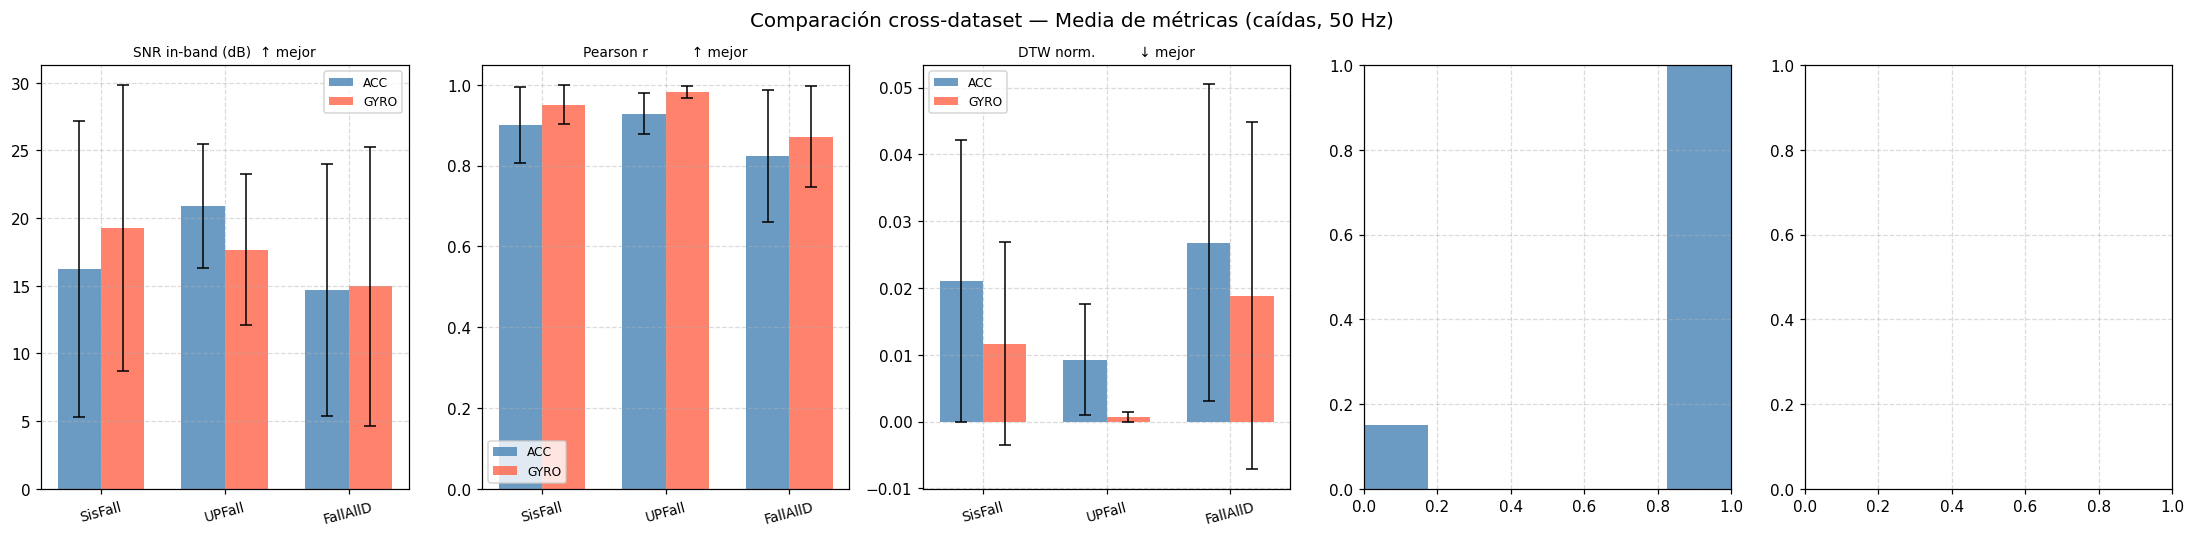

In [32]:
# ── 7b. Gráficos comparativos ─────────────────────────────────────────────
ds_names  = list(RESULTS.keys())
n_ds      = len(ds_names)
colors    = {"ACC": "steelblue", "GYRO": "tomato"}

fig, axes = plt.subplots(1, len(metrics_order), figsize=(5 * len(metrics_order), 5))
fig.suptitle("Comparación cross-dataset — Media de métricas (caídas, 50 Hz)", fontsize=13)

for ax, metric in zip(axes, metrics_order):
    x     = np.arange(n_ds)
    width = 0.35
    for i, sensor in enumerate(("ACC", "GYRO")):
        sub = df_summary[df_summary["Sensor"] == sensor]
        vals = [sub[sub["Dataset"] == ds][metric + "_mean"].values[0]
                if ds in sub["Dataset"].values else np.nan
                for ds in ds_names]
        p95  = [sub[sub["Dataset"] == ds][metric + "_p95"].values[0]
                if ds in sub["Dataset"].values else np.nan
                for ds in ds_names]
        err  = [p - v for p, v in zip(p95, vals)]
        bars = ax.bar(x + i * width, vals, width, label=sensor,
                      color=colors[sensor], alpha=0.8,
                      yerr=err, capsize=4, error_kw={"elinewidth": 1})

    ax.set_title(metric_labels[metric], fontsize=9)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(ds_names, rotation=15, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

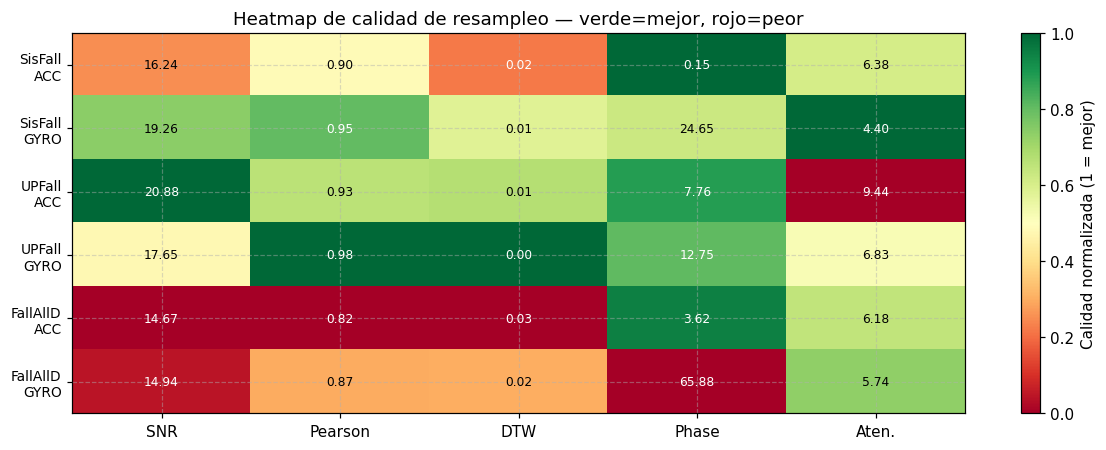


Nota: Los valores crudos están impresos dentro de cada celda.
La escala de color es relativa entre los datasets disponibles en RESULTS.


In [33]:
# ── 7c. Heatmap de calidad normalizada ───────────────────────────────────
# Convierte todas las métricas a una escala 0-1 donde 1 = mejor resultado.
# Permite ver de un vistazo qué dataset-sensor tiene el peor compromiso global.

from matplotlib.colors import Normalize
from matplotlib.cm import RdYlGn

# Métricas donde mayor = mejor
higher_is_better = {"snr_db", "pearson_r"}

heatmap_data = []
row_labels   = []

for _, r in df_summary.iterrows():
    row_labels.append(f"{r['Dataset']}\n{r['Sensor']}")
    heatmap_data.append([r[m + "_mean"] for m in metrics_order])

heatmap_arr = np.array(heatmap_data, dtype=float)

# Normalizar columna a columna
heatmap_norm = np.zeros_like(heatmap_arr)
for j, m in enumerate(metrics_order):
    col = heatmap_arr[:, j]
    mn, mx = np.nanmin(col), np.nanmax(col)
    if mx == mn:
        heatmap_norm[:, j] = 1.0
    elif m in higher_is_better:
        heatmap_norm[:, j] = (col - mn) / (mx - mn)
    else:
        heatmap_norm[:, j] = 1 - (col - mn) / (mx - mn)

col_labels = [metric_labels[m].split(" ")[0] for m in metrics_order]

fig, ax = plt.subplots(figsize=(len(metrics_order) * 2.2, max(4, len(row_labels) * 0.7)))
im = ax.imshow(heatmap_norm, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(len(row_labels)):
    for j in range(len(metrics_order)):
        raw_val = heatmap_arr[i, j]
        txt = f"{raw_val:.2f}" if abs(raw_val) < 100 else f"{raw_val:.0f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                color="black" if 0.25 < heatmap_norm[i, j] < 0.75 else "white")

plt.colorbar(im, ax=ax, label="Calidad normalizada (1 = mejor)")
ax.set_title("Heatmap de calidad de resampleo — verde=mejor, rojo=peor", fontsize=12)
plt.tight_layout()
plt.show()

print("\nNota: Los valores crudos están impresos dentro de cada celda.")
print("La escala de color es relativa entre los datasets disponibles en RESULTS.")